
===== FILE: Data_GG.csv =====
K-Push:
     time   force
0  0.000  0.5568
1  0.002  0.5443
2  0.004  0.5204
3  0.006  0.5267
4  0.008  0.4979

Wrist (S121577):
     time        qx        qy        qz        qw
0  0.000 -0.024048  0.608276  0.757263  0.236450
1  0.008 -0.023987  0.608316  0.757245  0.236484
2  0.016 -0.023865  0.608354  0.757192  0.236518
3  0.024 -0.023774  0.608357  0.757196  0.236488
4  0.032 -0.023713  0.608386  0.757225  0.236335

Shoulder (S121578):
     time        qx        qy        qz        qw
0  0.000 -0.592041  0.160645  0.017517  0.789490
1  0.008 -0.592120  0.160436  0.017579  0.789483
2  0.016 -0.592270  0.160069  0.017701  0.789449
3  0.024 -0.592358  0.159946  0.017762  0.789414
4  0.032 -0.592305  0.160162  0.017670  0.789394

Baseline wrist: [-0.049, 0.636, 0.742, 0.207]
Baseline shoulder: [-0.593, 0.166, 0.018, 0.787]

Shapes: (31630, 2) (7905, 5) (7905, 5)


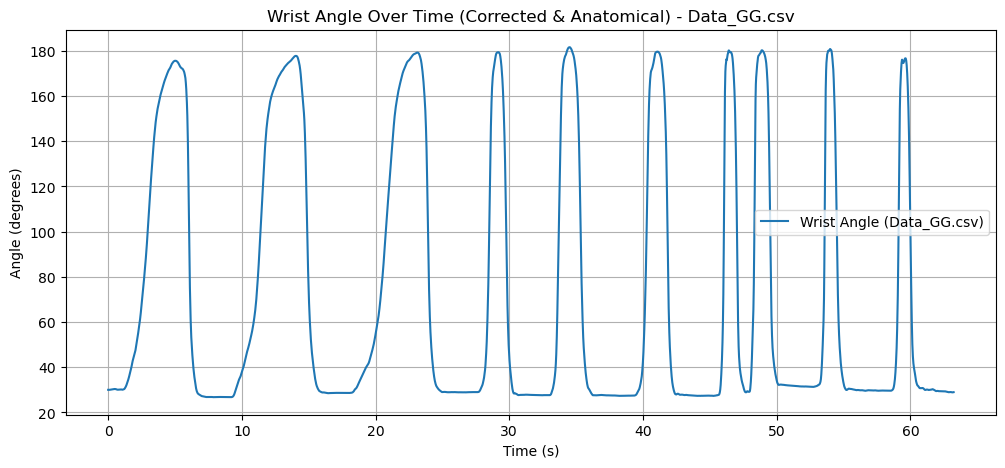

===== FILE: Data_GG.csv =====
Min angle: 26.721407057727433
Max angle: 181.5875169468768


KeyError: 'angle_filt'

In [11]:
import pandas as pd
import numpy as np
from io import StringIO
import os
## STEP 1: IMPORT LIBRARIES + CLEAN DATA  + DEFINE FUNCTIONS + CHECK FILES  + EXTRACT BASELINE VALUES

# ==========================================================
# FUNCTION: LOAD DATA FILE
# ==========================================================
def load_data(filename):
    """
    Load a data file from the ../data folder.

    Parameters:
        filename (str): name of the file (e.g. "Data_GG.csv")

    Returns:
        lines (list): all lines from the file
    """
    path = os.path.join("..", "data", filename)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    return lines


# ==========================================================
# FUNCTION: PROCESS ONE FILE
# ==========================================================
def process_file(filename):

    # ---------- STEP 1: LOAD FILE ----------
    lines = load_data(filename)

    # ---------- STEP 2: FIND K-PUSH AND K-MOVE BLOCKS ----------
    idx_push = None
    idx_move = None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    # ---------- STEP 3: SPLIT FILE ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- STEP 4: CLEAN K-PUSH ----------
    header_idx_push = next(i for i, line in enumerate(push_lines) if "temps (seconde)" in line)

    push_str = "".join(push_lines[header_idx_push:])

    df_push = pd.read_csv(
        StringIO(push_str),
        sep=r"\t|,",
        engine="python",
        on_bad_lines="skip"
    )

    df_push = df_push.dropna(axis=1, how='all')

    df_push = df_push.rename(columns={
        "temps (seconde)": "time",
        "CHANNEL_1": "force"
    })

    df_push = df_push[["time", "force"]]
    df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- STEP 5: ROBUST BASELINE EXTRACTION ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            # Try splitting with tab first
            parts = line.strip().split("\t")

            # If tab split fails → try comma
            if len(parts) < 5:
                parts = line.strip().split(",")

            sensor_name = parts[0]

            # Extract numeric values safely
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            # Keep only first 4 values (qx, qy, qz, qw)
            values = values[:4]

            # Assign values to correct sensor
            if "S121577" in sensor_name:
                baseline["wrist"] = values
            elif "S121578" in sensor_name:
                baseline["shoulder"] = values

    # ---------- FIND HEADER ----------
    header_idx_move = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)

    move_data_lines = move_lines[header_idx_move + 1:]

    # ---------- PARSE DATA ----------
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")

        if len(row) < 2:
            row = line.strip().split(",")

        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)

    df_move = df_move.dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce')
    df_move = df_move.ffill().bfill()

    # ---------- STEP 6: EXTRACT SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- FINAL CHECK ----------
    print(f"\n===== FILE: {filename} =====")

    print("K-Push:\n", df_push.head())

    print("\nWrist (S121577):\n", df_wrist.head())

    print("\nShoulder (S121578):\n", df_shoulder.head())

    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])

    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================

# ---------- SELECT FILE(S) ----------
files = ["Data_GG.csv"]

# files = ["Data_droite.csv", "Data_GG.csv"]  # for multiple files

# ---------- PROCESS FILE(S) ----------
results = {}

for file in files:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)

    results[file] = {
        "push": df_push,
        "wrist": df_wrist,
        "shoulder": df_shoulder,
        "baseline": baseline
    }

## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
    3. Convert to degrees
    4. Recalibrate so that:
       - max flexion = baseline_deg (manual reference from video)
       - extension increases toward ~180°
    """

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_GG.csv"]  # Example single file
# files = ["Data_droite.csv", "Data_GG.csv"]  # Multiple files

# Manual baseline angles for each file (from video analysis)
baseline_angles = {
    "Data_droite.csv": 30,
    "Data_GG.csv": 30
}

# Store results
angles_results = {}

for file in files:
    # Get wrist DataFrame from previous step (process_file)
    df_wrist = results[file]["wrist"]

    # Get manual baseline angle for this file
    manual_baseline = baseline_angles[file]

    # Convert quaternion → anatomical angle
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    # Store results
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())



# STEP 4 : EVENT DETECTION from the PEAK +  CHECK RESULTS WITH PLOTS

from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# ---------- STEP 5: EVENT DETECTION FROM FILTERED ANGLE ----------

# Use filtered angle
signal = df_wrist_angles["angle_filt"].values
time = df_wrist_angles["time"].values

# ---------- 1. DETECT EXTENSION (MAXIMA) ----------
peaks_extension, _ = find_peaks(
    signal,
    distance=200
)

# ---------- 2. DETECT FLEXION (MINIMA) ----------
peaks_flexion_all, _ = find_peaks(
    -signal,
    distance=200
)

# Get values
flexion_values = signal[peaks_flexion_all]

# Sort (lowest = strongest flexion)
sorted_indices = np.argsort(flexion_values)

# Keep 9 deepest minima
peaks_flexion = np.sort(peaks_flexion_all[sorted_indices[:9]])

# ---------- OPTIONAL FIX ----------
if signal[0] > signal[1]:
    peaks_extension = np.insert(peaks_extension, 0, 0)

# keep the 9 highest maxima
ext_values = signal[peaks_extension]
top_idx = np.argsort(ext_values)[-9:]
peaks_extension = np.sort(peaks_extension[top_idx])

# ---------- DEBUG ----------
print("Extension peaks (max):", peaks_extension)
print("Extension values:", signal[peaks_extension])

print("Flexion peaks (min):", peaks_flexion)
print("Flexion values:", signal[peaks_flexion])

print("Number of extension peaks:", len(peaks_extension))
print("Number of flexion peaks:", len(peaks_flexion))

# ---------- FORCE 1 MINIMUM BETWEEN EACH MAX ----------
peaks_flexion_fixed = []

for i in range(len(peaks_extension) - 1):
    start = peaks_extension[i]
    end = peaks_extension[i+1]

    # segment between two maxima
    segment = signal[start:end]

    if len(segment) == 0:
        continue

    # find minimum in this segment
    local_min_idx = np.argmin(segment)

    # convert to global index
    peaks_flexion_fixed.append(start + local_min_idx)

peaks_flexion_fixed = np.array(peaks_flexion_fixed)


plt.figure(figsize=(14,6))

plt.plot(time, signal, label="Filtered Angle", linewidth=2)

# Max (extension)
plt.plot(time[peaks_extension], signal[peaks_extension],
         "ro", label="Extension (max)")

# Min (flexion)
plt.plot(time[peaks_flexion_fixed], signal[peaks_flexion_fixed],
         "go", label="Flexion (min)")

plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.title("Event Detection (Robust Min/Max)")
plt.legend()
plt.grid(True)

plt.show()


===== FILE: Data_GG.csv =====
K-Push:
     time   force
0  0.000  0.5568
1  0.002  0.5443
2  0.004  0.5204
3  0.006  0.5267
4  0.008  0.4979

Wrist (S121577):
     time        qx        qy        qz        qw
0  0.000 -0.024048  0.608276  0.757263  0.236450
1  0.008 -0.023987  0.608316  0.757245  0.236484
2  0.016 -0.023865  0.608354  0.757192  0.236518
3  0.024 -0.023774  0.608357  0.757196  0.236488
4  0.032 -0.023713  0.608386  0.757225  0.236335

Shoulder (S121578):
     time        qx        qy        qz        qw
0  0.000 -0.592041  0.160645  0.017517  0.789490
1  0.008 -0.592120  0.160436  0.017579  0.789483
2  0.016 -0.592270  0.160069  0.017701  0.789449
3  0.024 -0.592358  0.159946  0.017762  0.789414
4  0.032 -0.592305  0.160162  0.017670  0.789394

Baseline wrist: [-0.049, 0.636, 0.742, 0.207]
Baseline shoulder: [-0.593, 0.166, 0.018, 0.787]

Shapes: (31630, 2) (7905, 5) (7905, 5)


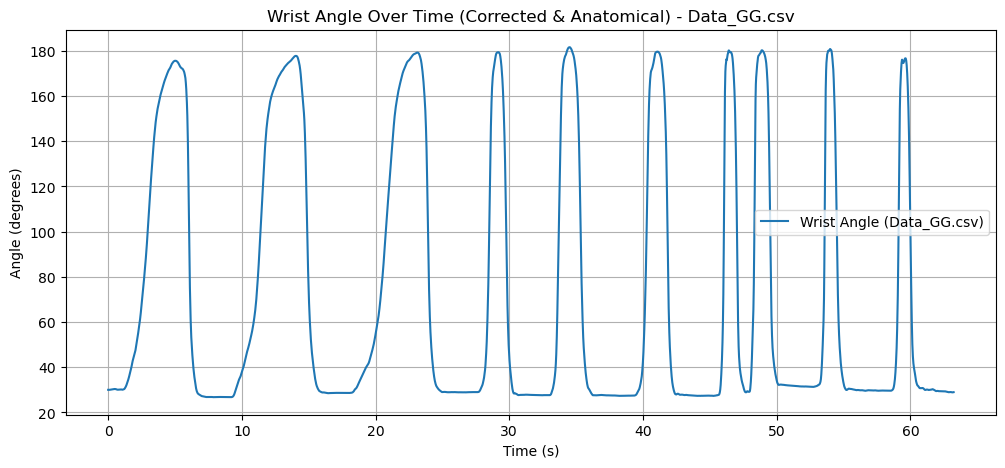

===== FILE: Data_GG.csv =====
Min angle: 26.721407057727433
Max angle: 181.5875169468768
First 5 rows with filtered angle:
     time      angle  angle_filt
0  0.000  30.000000   29.999890
1  0.008  29.993578   29.994153
2  0.016  29.988104   29.988808
3  0.024  29.987324   29.984173
4  0.032  29.981599   29.980514


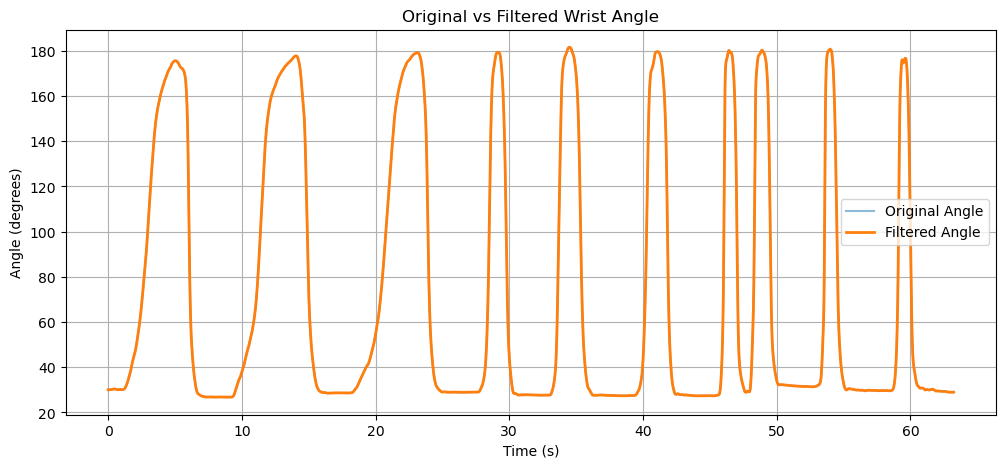

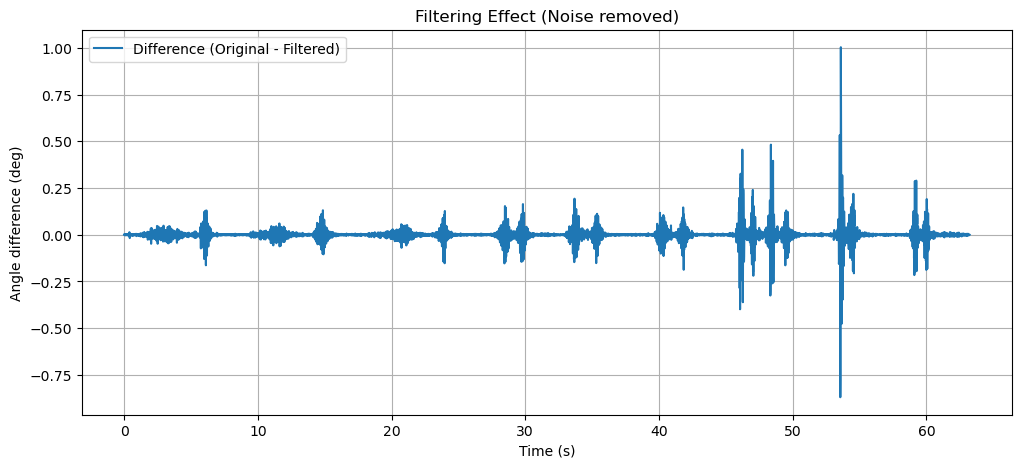

Extension peaks (max): [1755 2890 3647 4314 5137 5803 6112 6749 7453]
Extension values: [177.75671611 179.20859291 179.39245948 181.58940503 179.65596377
 180.15945653 180.2572645  180.76144024 176.70523512]
Flexion peaks (min): [ 920 1140 2060 3837 4061 4562 4811 5445 5660]
Flexion values: [26.80292357 26.71978837 28.49757873 27.66348187 27.60737161 27.56069195
 27.31436486 27.50991102 27.30888692]
Number of extension peaks: 9
Number of flexion peaks: 9


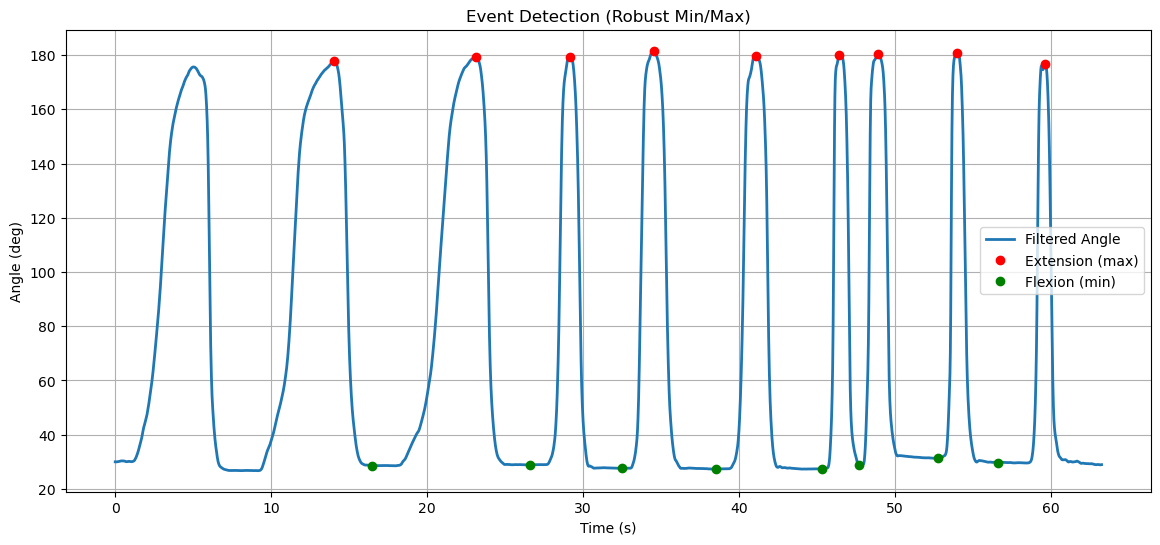

In [ ]:
import pandas as pd
import numpy as np
from io import StringIO
import os
## STEP 1: IMPORT LIBRARIES + CLEAN DATA  + DEFINE FUNCTIONS + CHECK FILES  + EXTRACT BASELINE VALUES

# ==========================================================
# FUNCTION: LOAD DATA FILE
# ==========================================================
def load_data(filename):
    """
    Load a data file from the ../data folder.

    Parameters:
        filename (str): name of the file (e.g. "Data_GG.csv")

    Returns:
        lines (list): all lines from the file
    """
    path = os.path.join("..", "data", filename)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    return lines


# ==========================================================
# FUNCTION: PROCESS ONE FILE
# ==========================================================
def process_file(filename):

    # ---------- STEP 1: LOAD FILE ----------
    lines = load_data(filename)

    # ---------- STEP 2: FIND K-PUSH AND K-MOVE BLOCKS ----------
    idx_push = None
    idx_move = None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    # ---------- STEP 3: SPLIT FILE ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- STEP 4: CLEAN K-PUSH ----------
    header_idx_push = next(i for i, line in enumerate(push_lines) if "temps (seconde)" in line)

    push_str = "".join(push_lines[header_idx_push:])

    df_push = pd.read_csv(
        StringIO(push_str),
        sep=r"\t|,",
        engine="python",
        on_bad_lines="skip"
    )

    df_push = df_push.dropna(axis=1, how='all')

    df_push = df_push.rename(columns={
        "temps (seconde)": "time",
        "CHANNEL_1": "force"
    })

    df_push = df_push[["time", "force"]]
    df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- STEP 5: ROBUST BASELINE EXTRACTION ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            # Try splitting with tab first
            parts = line.strip().split("\t")

            # If tab split fails → try comma
            if len(parts) < 5:
                parts = line.strip().split(",")

            sensor_name = parts[0]

            # Extract numeric values safely
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            # Keep only first 4 values (qx, qy, qz, qw)
            values = values[:4]

            # Assign values to correct sensor
            if "S121577" in sensor_name:
                baseline["wrist"] = values
            elif "S121578" in sensor_name:
                baseline["shoulder"] = values

    # ---------- FIND HEADER ----------
    header_idx_move = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)

    move_data_lines = move_lines[header_idx_move + 1:]

    # ---------- PARSE DATA ----------
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")

        if len(row) < 2:
            row = line.strip().split(",")

        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)

    df_move = df_move.dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce')
    df_move = df_move.ffill().bfill()

    # ---------- STEP 6: EXTRACT SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- FINAL CHECK ----------
    print(f"\n===== FILE: {filename} =====")

    print("K-Push:\n", df_push.head())

    print("\nWrist (S121577):\n", df_wrist.head())

    print("\nShoulder (S121578):\n", df_shoulder.head())

    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])

    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================

# ---------- SELECT FILE(S) ----------
files = ["Data_GG.csv"]

# files = ["Data_droite.csv", "Data_GG.csv"]  # for multiple files

# ---------- PROCESS FILE(S) ----------
results = {}

for file in files:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)

    results[file] = {
        "push": df_push,
        "wrist": df_wrist,
        "shoulder": df_shoulder,
        "baseline": baseline
    }

## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
    3. Convert to degrees
    4. Recalibrate so that:
       - max flexion = baseline_deg (manual reference from video)
       - extension increases toward ~180°
    """

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_GG.csv"]  # Example single file
# files = ["Data_droite.csv", "Data_GG.csv"]  # Multiple files

# Manual baseline angles for each file (from video analysis)
baseline_angles = {
    "Data_droite.csv": 30,
    "Data_GG.csv": 30
}

# Store results
angles_results = {}

for file in files:
    # Get wrist DataFrame from previous step (process_file)
    df_wrist = results[file]["wrist"]

    # Get manual baseline angle for this file
    manual_baseline = baseline_angles[file]

    # Convert quaternion → anatomical angle
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    # Store results
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())


## STEP 3 : FILTER the data  + Chek results with plots 

from scipy.signal import butter, filtfilt

def lowpass_filter(signal, fs, cutoff=10, order=4):
    """
    Apply a Butterworth low-pass filter.

    Parameters:
        signal : array-like
        fs : sampling frequency (Hz)
        cutoff : cutoff frequency (Hz)
        order : filter order

    Returns:
        filtered_signal
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_signal = filtfilt(b, a, signal)

    return filtered_signal

# ---------- APPLY FILTER TO ANGLE ----------
fs = 125  # sampling frequency

df_wrist_angles["angle_filt"] = lowpass_filter(
    df_wrist_angles["angle"],
    fs=fs,
    cutoff=10
)
# ---------- CHECK ----------
print("First 5 rows with filtered angle:\n", df_wrist_angles.head())
plt.figure(figsize=(12,5))
plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["angle"],
    label="Original Angle",
    alpha=0.5
)
plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["angle_filt"],
    label="Filtered Angle",
    linewidth=2
)
plt.xlabel("Time (s)")
plt.ylabel("Angle (degrees)")
plt.title("Original vs Filtered Wrist Angle")
plt.legend()
plt.grid(True)
plt.show()   

# Difference signal
df_wrist_angles["diff"] = df_wrist_angles["angle"] - df_wrist_angles["angle_filt"]

plt.figure(figsize=(12,5))

plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["diff"],
    label="Difference (Original - Filtered)"
)

plt.xlabel("Time (s)")
plt.ylabel("Angle difference (deg)")
plt.title("Filtering Effect (Noise removed)")
plt.legend()
plt.grid(True)

plt.show()



# STEP 3 : EVENT DETECTION from the PEAK +  CHECK RESULTS WITH PLOTS

from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# ---------- STEP 5: EVENT DETECTION FROM FILTERED ANGLE ----------

# Use filtered angle
signal = df_wrist_angles["angle_filt"].values
time = df_wrist_angles["time"].values

# ---------- 1. DETECT EXTENSION (MAXIMA) ----------
peaks_extension, _ = find_peaks(
    signal,
    distance=200
)

# ---------- 2. DETECT FLEXION (MINIMA) ----------
peaks_flexion_all, _ = find_peaks(
    -signal,
    distance=200
)

# Get values
flexion_values = signal[peaks_flexion_all]

# Sort (lowest = strongest flexion)
sorted_indices = np.argsort(flexion_values)

# Keep 9 deepest minima
peaks_flexion = np.sort(peaks_flexion_all[sorted_indices[:9]])

# ---------- OPTIONAL FIX ----------
if signal[0] > signal[1]:
    peaks_extension = np.insert(peaks_extension, 0, 0)

# keep the 9 highest maxima
ext_values = signal[peaks_extension]
top_idx = np.argsort(ext_values)[-9:]
peaks_extension = np.sort(peaks_extension[top_idx])

# ---------- DEBUG ----------
print("Extension peaks (max):", peaks_extension)
print("Extension values:", signal[peaks_extension])

print("Flexion peaks (min):", peaks_flexion)
print("Flexion values:", signal[peaks_flexion])

print("Number of extension peaks:", len(peaks_extension))
print("Number of flexion peaks:", len(peaks_flexion))

# ---------- FORCE 1 MINIMUM BETWEEN EACH MAX ----------
peaks_flexion_fixed = []

for i in range(len(peaks_extension) - 1):
    start = peaks_extension[i]
    end = peaks_extension[i+1]

    # segment between two maxima
    segment = signal[start:end]

    if len(segment) == 0:
        continue

    # find minimum in this segment
    local_min_idx = np.argmin(segment)

    # convert to global index
    peaks_flexion_fixed.append(start + local_min_idx)

peaks_flexion_fixed = np.array(peaks_flexion_fixed)


plt.figure(figsize=(14,6))

plt.plot(time, signal, label="Filtered Angle", linewidth=2)

# Max (extension)
plt.plot(time[peaks_extension], signal[peaks_extension],
         "ro", label="Extension (max)")

# Min (flexion)
plt.plot(time[peaks_flexion_fixed], signal[peaks_flexion_fixed],
         "go", label="Flexion (min)")

plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.title("Event Detection (Robust Min/Max)")
plt.legend()
plt.grid(True)

plt.show()





===== FILE: Data_Ch_D.csv =====

K-Push:
     time  force
0  0.000    0.0
1  0.001    0.0
2  0.002    0.0
3  0.003    0.0
4  0.004    0.0

Wrist (S121577):
     time        qx        qy        qz        qw
0  0.000  0.396362  0.516846  0.433289  0.622803
1  0.004  0.396376  0.516894  0.433273  0.622825
2  0.008  0.396373  0.516982  0.433239  0.622789
3  0.012  0.396370  0.517070  0.433206  0.622754
4  0.016  0.396342  0.517134  0.433178  0.622728

Shoulder (S121578):
     time        qx        qy        qz        qw
0  0.000 -0.573059  0.038269  0.100220  0.812439
1  0.004 -0.573072  0.038239  0.100222  0.812427
2  0.008 -0.573105  0.038179  0.100222  0.812400
3  0.012 -0.573163  0.038148  0.100252  0.812365
4  0.016 -0.573195  0.038117  0.100283  0.812336

Baseline wrist: [0.383, 0.513, 0.399, 0.656]
Baseline shoulder: [-0.568, 0.031, 0.1, 0.816]

Shapes: (47382, 2) (11835, 5) (11835, 5)


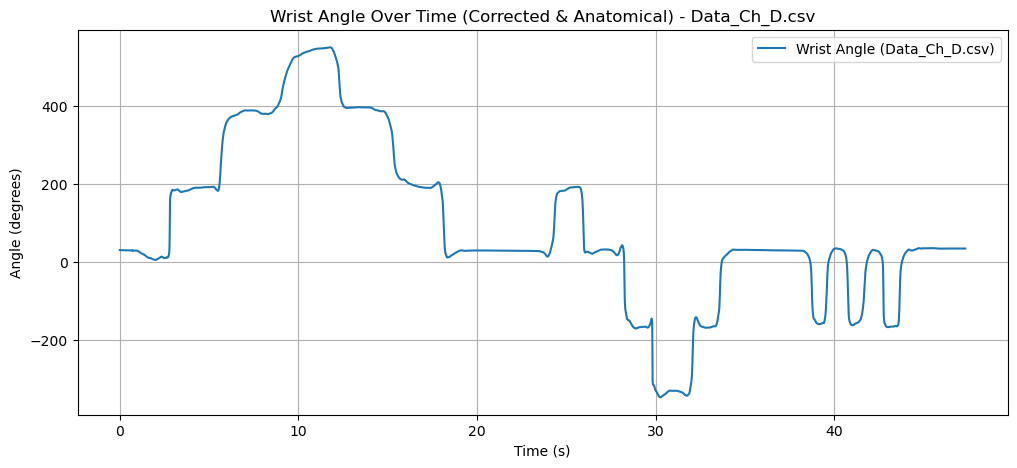

===== FILE: Data_Ch_D.csv =====
Min angle: -346.76925568226636
Max angle: 549.6281723034925
First 5 rows with filtered angle:
     time      angle  angle_filt
0  0.000  30.000000   30.000144
1  0.004  29.992151   29.991697
2  0.008  29.981593   29.983466
3  0.012  29.971033   29.975688
4  0.016  29.966047   29.968512


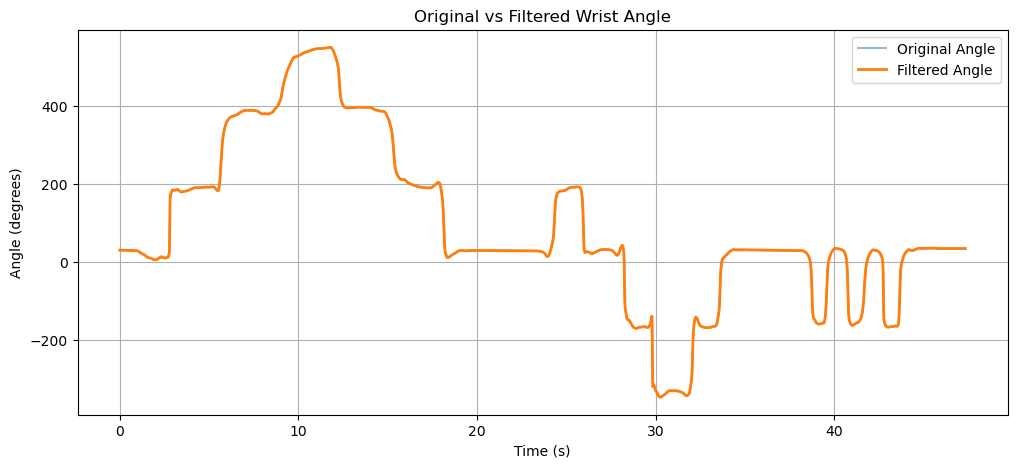

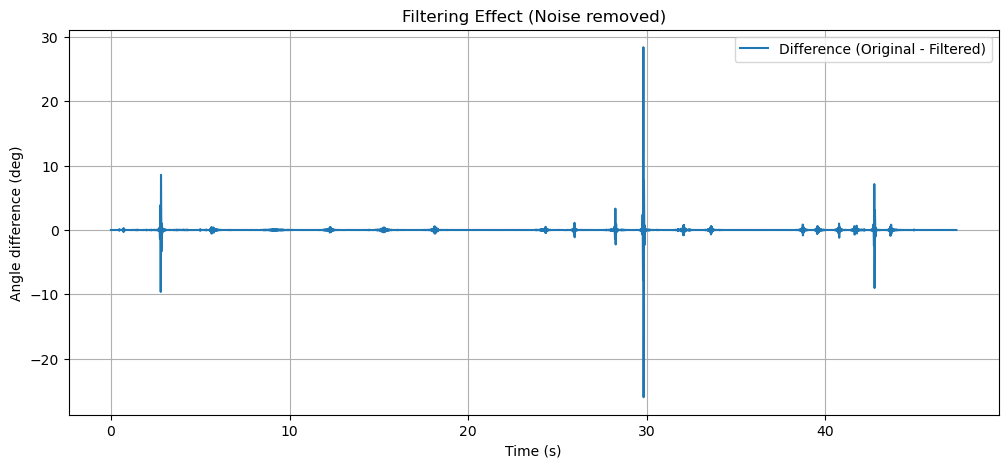

Extension peaks (max): [1304 1823 2033 2943 3344 3691 3973 4456 6408]
Extension values: [192.39852758 388.10499939 379.52049057 549.62314424 396.13464988
 385.92478149 211.0796734  203.78561378 192.08452084]
Flexion peaks (min): [  503  4582  7225  7564  7939  8209  9791 10253 10752]
Flexion values: [   4.69549737   11.23900987 -170.7059744  -346.76371917 -342.94385622
 -168.6970668  -159.52299801 -162.6314539  -167.53710537]
Number of extension peaks: 9
Number of flexion peaks: 9


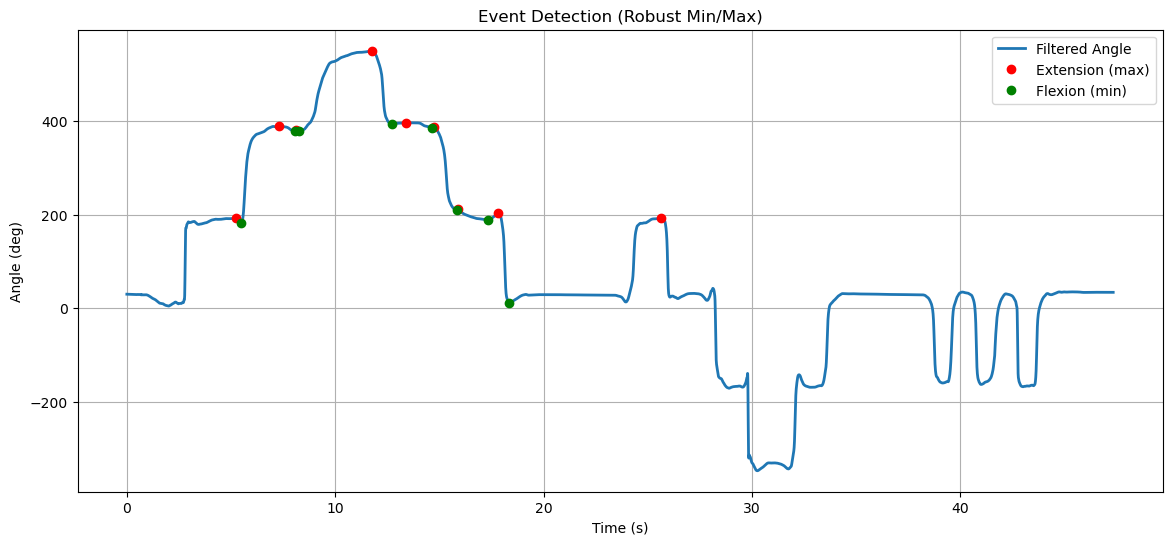

In [14]:
import pandas as pd
import numpy as np
from io import StringIO
import os

# Affichage complet Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# ==========================================================
# LOAD DATA FILE
# ==========================================================
def load_data(filename):
    path = os.path.join("..", "data", filename)
    with open(path, "r", encoding="utf-8") as f:
        return f.readlines()


# ==========================================================
# PROCESS ONE FILE
# ==========================================================
def process_file(filename):
    lines = load_data(filename)

    # ---------- FIND BLOCKS ----------
    idx_push = None
    idx_move = None
    for i, line in enumerate(lines):
        if "K-Push" in line and idx_push is None:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    if idx_push is None:
        print("❌ K-PUSH NOT FOUND")
        return None, None, None, None
    if idx_move is None:
        print("❌ K-MOVE NOT FOUND")
        return None, None, None, None

    # ---------- SPLIT BLOCKS (ORDER INDEPENDENT) ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        move_lines = lines[idx_move:idx_push]
        push_lines = lines[idx_push:]

    # ---------- CLEAN K-PUSH ----------
    try:
        header_idx_push = next(i for i, line in enumerate(push_lines) if "temps" in line.lower())
    except StopIteration:
        print("❌ Header K-Push non trouvé")
        return None, None, None, None

    push_str = "".join(push_lines[header_idx_push:])
    df_push = pd.read_csv(StringIO(push_str), sep=r"\t|,", engine="python", on_bad_lines="skip")
    df_push = df_push.dropna(axis=1, how='all')
    df_push = df_push.rename(columns={"temps (seconde)": "time", "CHANNEL_1": "force"})
    if "time" in df_push.columns and "force" in df_push.columns:
        df_push = df_push[["time", "force"]]
        df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()
    else:
        df_push = pd.DataFrame()

    # ---------- BASELINE ----------
    baseline = {"wrist": [], "shoulder": []}
    for line in lines:
        if "Quaternion de base" in line:
            parts = line.strip().split("\t")
            if len(parts) < 5:
                parts = line.strip().split(",")
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue
            values = values[:4]
            if "S121577" in parts[0]:
                baseline["wrist"] = values
            elif "S121578" in parts[0]:
                baseline["shoulder"] = values

    # ---------- CLEAN K-MOVE ----------
    try:
        header_idx_move = next(i for i, line in enumerate(move_lines) if "temps" in line.lower())
    except StopIteration:
        print("❌ Header K-Move non trouvé")
        return df_push, pd.DataFrame(), pd.DataFrame(), baseline

    move_data_lines = move_lines[header_idx_move + 1:]
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")
        if len(row) < 2:
            row = line.strip().split(",")
        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)
    df_move = df_move.replace("", np.nan).dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce').ffill().bfill()

    # ---------- EXTRACT SENSORS ----------
    try:
        df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
        df_wrist.columns = ["time","qx","qy","qz","qw"]
        df_shoulder = df_move.iloc[:, [0,5,6,7,8]].copy()
        df_shoulder.columns = ["time","qx","qy","qz","qw"]
    except:
        df_wrist = pd.DataFrame()
        df_shoulder = pd.DataFrame()

    # ---------- RETURN ----------
    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================
files = ["Data_Ch_D.csv"]  # liste des fichiers

results = {}

for file in files:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)
    results[file] = {"push": df_push, "wrist": df_wrist, "shoulder": df_shoulder, "baseline": baseline}

    # ---------- FULL DISPLAY ----------
    print(f"\n===== FILE: {file} =====")
    print("\nK-Push:\n", df_push.head())
    print("\nWrist (S121577):\n", df_wrist.head())
    print("\nShoulder (S121578):\n", df_shoulder.head())
    print("\nBaseline wrist:", baseline.get("wrist", []))
    print("Baseline shoulder:", baseline.get("shoulder", []))
    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)


## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
    3. Convert to degrees
    4. Recalibrate so that:
       - max flexion = baseline_deg (manual reference from video)
       - extension increases toward ~180°
    """

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_Ch_D.csv"]  # Example single file
# files = ["Data_droite.csv", "Data_GG.csv"]  # Multiple files

# Manual baseline angles for each file (from video analysis)
baseline_angles = {
    "Data_Ch_D.csv": 30,
 
}

# Store results
angles_results = {}

for file in files:
    # Get wrist DataFrame from previous step (process_file)
    df_wrist = results[file]["wrist"]

    # Get manual baseline angle for this file
    manual_baseline = baseline_angles[file]

    # Convert quaternion → anatomical angle
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    # Store results
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())


## STEP 3 : FILTER the data  + Chek results with plots 

from scipy.signal import butter, filtfilt

def lowpass_filter(signal, fs, cutoff=10, order=4):
    """
    Apply a Butterworth low-pass filter.

    Parameters:
        signal : array-like
        fs : sampling frequency (Hz)
        cutoff : cutoff frequency (Hz)
        order : filter order

    Returns:
        filtered_signal
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_signal = filtfilt(b, a, signal)

    return filtered_signal

# ---------- APPLY FILTER TO ANGLE ----------
fs = 125  # sampling frequency

df_wrist_angles["angle_filt"] = lowpass_filter(
    df_wrist_angles["angle"],
    fs=fs,
    cutoff=10
)
# ---------- CHECK ----------
print("First 5 rows with filtered angle:\n", df_wrist_angles.head())
plt.figure(figsize=(12,5))
plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["angle"],
    label="Original Angle",
    alpha=0.5
)
plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["angle_filt"],
    label="Filtered Angle",
    linewidth=2
)
plt.xlabel("Time (s)")
plt.ylabel("Angle (degrees)")
plt.title("Original vs Filtered Wrist Angle")
plt.legend()
plt.grid(True)
plt.show()   

# Difference signal
df_wrist_angles["diff"] = df_wrist_angles["angle"] - df_wrist_angles["angle_filt"]

plt.figure(figsize=(12,5))

plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["diff"],
    label="Difference (Original - Filtered)"
)

plt.xlabel("Time (s)")
plt.ylabel("Angle difference (deg)")
plt.title("Filtering Effect (Noise removed)")
plt.legend()
plt.grid(True)

plt.show()



# STEP 3 : EVENT DETECTION from the PEAK +  CHECK RESULTS WITH PLOTS

from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# ---------- STEP 5: EVENT DETECTION FROM FILTERED ANGLE ----------

# Use filtered angle
signal = df_wrist_angles["angle_filt"].values
time = df_wrist_angles["time"].values

# ---------- 1. DETECT EXTENSION (MAXIMA) ----------
peaks_extension, _ = find_peaks(
    signal,
    distance=200
)

# ---------- 2. DETECT FLEXION (MINIMA) ----------
peaks_flexion_all, _ = find_peaks(
    -signal,
    distance=200
)

# Get values
flexion_values = signal[peaks_flexion_all]

# Sort (lowest = strongest flexion)
sorted_indices = np.argsort(flexion_values)

# Keep 9 deepest minima
peaks_flexion = np.sort(peaks_flexion_all[sorted_indices[:9]])

# ---------- OPTIONAL FIX ----------
if signal[0] > signal[1]:
    peaks_extension = np.insert(peaks_extension, 0, 0)

# keep the 9 highest maxima
ext_values = signal[peaks_extension]
top_idx = np.argsort(ext_values)[-9:]
peaks_extension = np.sort(peaks_extension[top_idx])

# ---------- DEBUG ----------
print("Extension peaks (max):", peaks_extension)
print("Extension values:", signal[peaks_extension])

print("Flexion peaks (min):", peaks_flexion)
print("Flexion values:", signal[peaks_flexion])

print("Number of extension peaks:", len(peaks_extension))
print("Number of flexion peaks:", len(peaks_flexion))

# ---------- FORCE 1 MINIMUM BETWEEN EACH MAX ----------
peaks_flexion_fixed = []

for i in range(len(peaks_extension) - 1):
    start = peaks_extension[i]
    end = peaks_extension[i+1]

    # segment between two maxima
    segment = signal[start:end]

    if len(segment) == 0:
        continue

    # find minimum in this segment
    local_min_idx = np.argmin(segment)

    # convert to global index
    peaks_flexion_fixed.append(start + local_min_idx)

peaks_flexion_fixed = np.array(peaks_flexion_fixed)


plt.figure(figsize=(14,6))

plt.plot(time, signal, label="Filtered Angle", linewidth=2)

# Max (extension)
plt.plot(time[peaks_extension], signal[peaks_extension],
         "ro", label="Extension (max)")

# Min (flexion)
plt.plot(time[peaks_flexion_fixed], signal[peaks_flexion_fixed],
         "go", label="Flexion (min)")

plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.title("Event Detection (Robust Min/Max)")
plt.legend()
plt.grid(True)

plt.show()








===== FILE: Data_Lo_D_1.csv =====

K-Push:
     time   force
0  0.000  0.4864
1  0.001  0.4776
2  0.002  0.4503
3  0.003  0.4519
4  0.004  0.4711

Wrist (S121577):
     time        qx        qy        qz        qw
0  0.000  0.476135  0.443481  0.257568  0.714233
1  0.004  0.476059  0.443648  0.257607  0.714226
2  0.008  0.475903  0.443951  0.257666  0.714130
3  0.012  0.475748  0.444284  0.257665  0.714034
4  0.016  0.475593  0.444586  0.257633  0.713969

Shoulder (S121578):
     time        qx        qy        qz        qw
0  0.000 -0.492126  0.111816 -0.044678  0.862122
1  0.004 -0.492139  0.111880 -0.044679  0.862112
2  0.008 -0.492142  0.111973 -0.044710  0.862088
3  0.012 -0.492168  0.112002 -0.044740  0.862079
4  0.016 -0.492228  0.112002 -0.044770  0.862047

Baseline wrist: [0.446, 0.468, 0.205, 0.735]
Baseline shoulder: [-0.482, 0.116, -0.05, 0.867]

Shapes: (50000, 2) (12505, 5) (12505, 5)


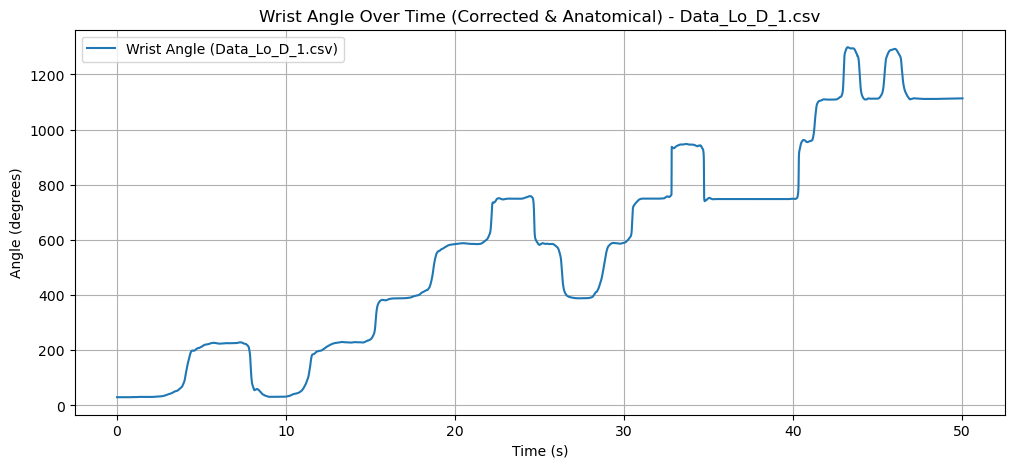

===== FILE: Data_Lo_D_1.csv =====
Min angle: 29.94861325483116
Max angle: 1298.639452213942
First 5 rows with filtered angle:
     time      angle  angle_filt
0  0.000  30.000000   30.000005
1  0.004  30.009285   30.013469
2  0.008  30.022918   30.026524
3  0.012  30.039641   30.038787
4  0.016  30.052900   30.049935


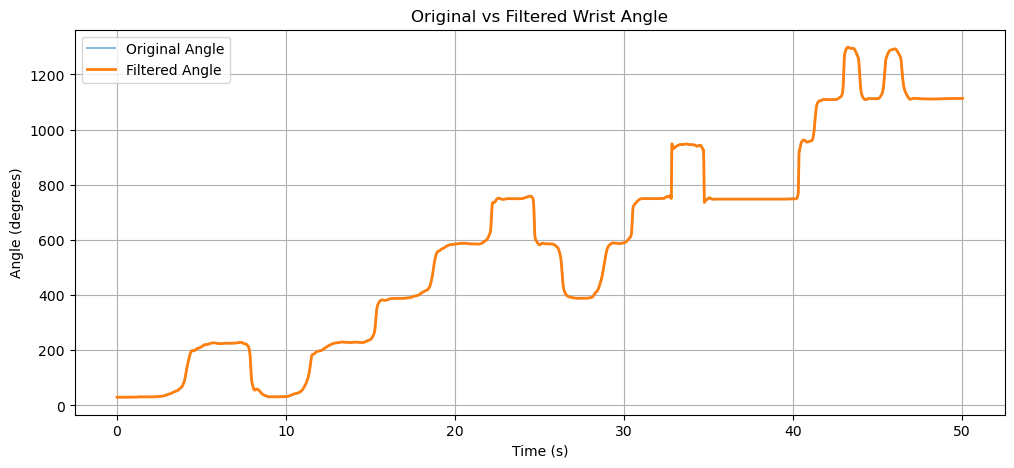

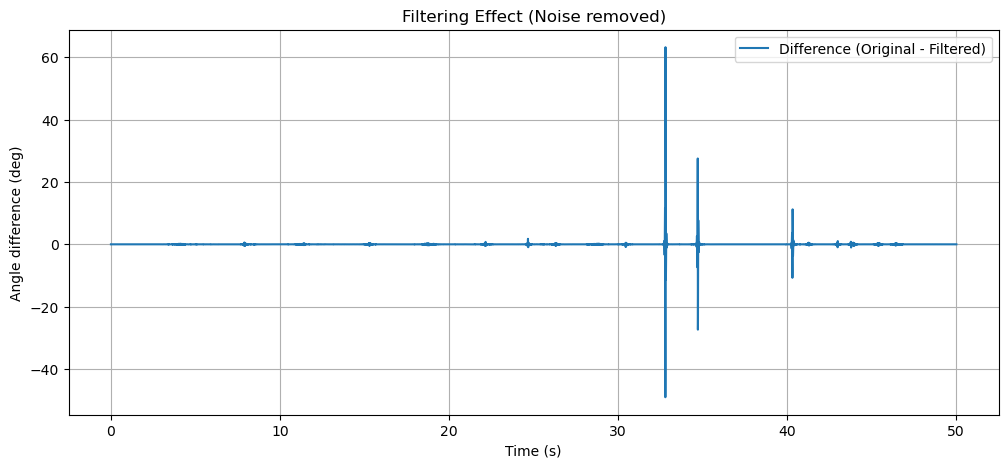

Extension peaks (max): [ 8207 10150 10457 10807 11115 11503 11789 12016 12364]
Extension values: [ 948.69677273  962.19292923 1109.70156807 1298.6297314  1113.02563297
 1292.63473616 1113.64491    1111.18099171 1112.68145448]
Flexion peaks (min): [ 198  512 1129 1512 1752 2031 2252 2457 3000]
Flexion values: [ 29.95080726  30.91062562 198.33153362 223.97827807 226.07398937
  55.67331833  31.35129584  31.43433359 198.07753215]
Number of extension peaks: 9
Number of flexion peaks: 9


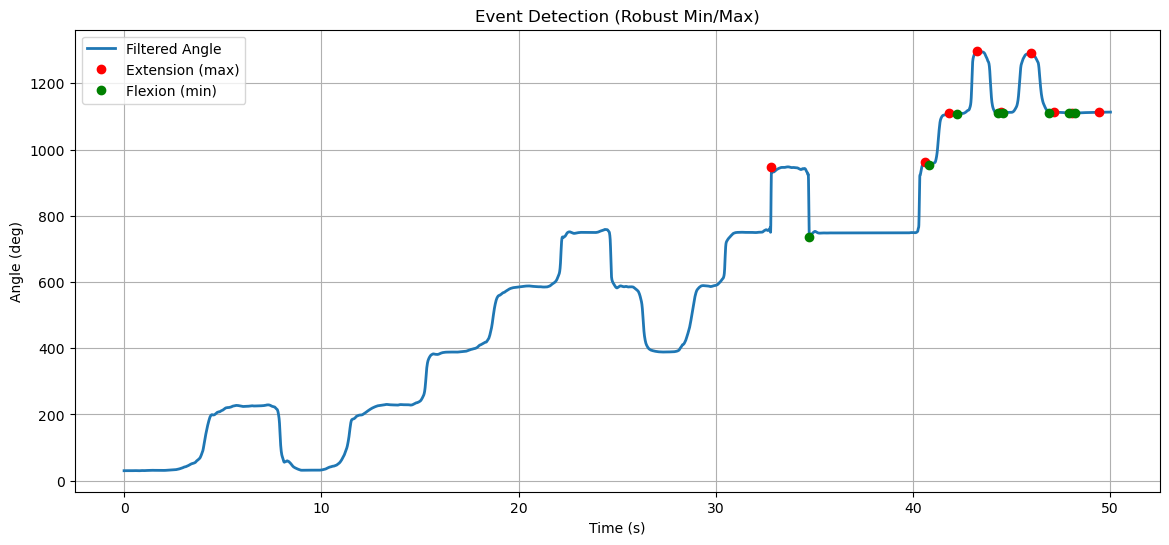

In [15]:
import pandas as pd
import numpy as np
from io import StringIO
import os

# Affichage complet Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# ==========================================================
# LOAD DATA FILE
# ==========================================================
def load_data(filename):
    path = os.path.join("..", "data", filename)
    with open(path, "r", encoding="utf-8") as f:
        return f.readlines()


# ==========================================================
# PROCESS ONE FILE
# ==========================================================
def process_file(filename):
    lines = load_data(filename)

    # ---------- FIND BLOCKS ----------
    idx_push = None
    idx_move = None
    for i, line in enumerate(lines):
        if "K-Push" in line and idx_push is None:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    if idx_push is None:
        print("❌ K-PUSH NOT FOUND")
        return None, None, None, None
    if idx_move is None:
        print("❌ K-MOVE NOT FOUND")
        return None, None, None, None

    # ---------- SPLIT BLOCKS (ORDER INDEPENDENT) ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        move_lines = lines[idx_move:idx_push]
        push_lines = lines[idx_push:]

    # ---------- CLEAN K-PUSH ----------
    try:
        header_idx_push = next(i for i, line in enumerate(push_lines) if "temps" in line.lower())
    except StopIteration:
        print("❌ Header K-Push non trouvé")
        return None, None, None, None

    push_str = "".join(push_lines[header_idx_push:])
    df_push = pd.read_csv(StringIO(push_str), sep=r"\t|,", engine="python", on_bad_lines="skip")
    df_push = df_push.dropna(axis=1, how='all')
    df_push = df_push.rename(columns={"temps (seconde)": "time", "CHANNEL_1": "force"})
    if "time" in df_push.columns and "force" in df_push.columns:
        df_push = df_push[["time", "force"]]
        df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()
    else:
        df_push = pd.DataFrame()

    # ---------- BASELINE ----------
    baseline = {"wrist": [], "shoulder": []}
    for line in lines:
        if "Quaternion de base" in line:
            parts = line.strip().split("\t")
            if len(parts) < 5:
                parts = line.strip().split(",")
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue
            values = values[:4]
            if "S121577" in parts[0]:
                baseline["wrist"] = values
            elif "S121578" in parts[0]:
                baseline["shoulder"] = values

    # ---------- CLEAN K-MOVE ----------
    try:
        header_idx_move = next(i for i, line in enumerate(move_lines) if "temps" in line.lower())
    except StopIteration:
        print("❌ Header K-Move non trouvé")
        return df_push, pd.DataFrame(), pd.DataFrame(), baseline

    move_data_lines = move_lines[header_idx_move + 1:]
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")
        if len(row) < 2:
            row = line.strip().split(",")
        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)
    df_move = df_move.replace("", np.nan).dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce').ffill().bfill()

    # ---------- EXTRACT SENSORS ----------
    try:
        df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
        df_wrist.columns = ["time","qx","qy","qz","qw"]
        df_shoulder = df_move.iloc[:, [0,5,6,7,8]].copy()
        df_shoulder.columns = ["time","qx","qy","qz","qw"]
    except:
        df_wrist = pd.DataFrame()
        df_shoulder = pd.DataFrame()

    # ---------- RETURN ----------
    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================
files = ["Data_Lo_D_1.csv"]  # liste des fichiers

results = {}

for file in files:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)
    results[file] = {"push": df_push, "wrist": df_wrist, "shoulder": df_shoulder, "baseline": baseline}

    # ---------- FULL DISPLAY ----------
    print(f"\n===== FILE: {file} =====")
    print("\nK-Push:\n", df_push.head())
    print("\nWrist (S121577):\n", df_wrist.head())
    print("\nShoulder (S121578):\n", df_shoulder.head())
    print("\nBaseline wrist:", baseline.get("wrist", []))
    print("Baseline shoulder:", baseline.get("shoulder", []))
    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)


## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
    3. Convert to degrees
    4. Recalibrate so that:
       - max flexion = baseline_deg (manual reference from video)
       - extension increases toward ~180°
    """

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_Lo_D_1.csv"]  # Example single file
# files = ["Data_droite.csv", "Data_GG.csv"]  # Multiple files

# Manual baseline angles for each file (from video analysis)
baseline_angles = {
    "Data_Lo_D_1.csv": 30,
 
}

# Store results
angles_results = {}

for file in files:
    # Get wrist DataFrame from previous step (process_file)
    df_wrist = results[file]["wrist"]

    # Get manual baseline angle for this file
    manual_baseline = baseline_angles[file]

    # Convert quaternion → anatomical angle
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    # Store results
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())


## STEP 3 : FILTER the data  + Chek results with plots 

from scipy.signal import butter, filtfilt

def lowpass_filter(signal, fs, cutoff=10, order=4):
    """
    Apply a Butterworth low-pass filter.

    Parameters:
        signal : array-like
        fs : sampling frequency (Hz)
        cutoff : cutoff frequency (Hz)
        order : filter order

    Returns:
        filtered_signal
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_signal = filtfilt(b, a, signal)

    return filtered_signal

# ---------- APPLY FILTER TO ANGLE ----------
fs = 125  # sampling frequency

df_wrist_angles["angle_filt"] = lowpass_filter(
    df_wrist_angles["angle"],
    fs=fs,
    cutoff=10
)
# ---------- CHECK ----------
print("First 5 rows with filtered angle:\n", df_wrist_angles.head())
plt.figure(figsize=(12,5))
plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["angle"],
    label="Original Angle",
    alpha=0.5
)
plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["angle_filt"],
    label="Filtered Angle",
    linewidth=2
)
plt.xlabel("Time (s)")
plt.ylabel("Angle (degrees)")
plt.title("Original vs Filtered Wrist Angle")
plt.legend()
plt.grid(True)
plt.show()   

# Difference signal
df_wrist_angles["diff"] = df_wrist_angles["angle"] - df_wrist_angles["angle_filt"]

plt.figure(figsize=(12,5))

plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["diff"],
    label="Difference (Original - Filtered)"
)

plt.xlabel("Time (s)")
plt.ylabel("Angle difference (deg)")
plt.title("Filtering Effect (Noise removed)")
plt.legend()
plt.grid(True)

plt.show()



# STEP 3 : EVENT DETECTION from the PEAK +  CHECK RESULTS WITH PLOTS

from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# ---------- STEP 5: EVENT DETECTION FROM FILTERED ANGLE ----------

# Use filtered angle
signal = df_wrist_angles["angle_filt"].values
time = df_wrist_angles["time"].values

# ---------- 1. DETECT EXTENSION (MAXIMA) ----------
peaks_extension, _ = find_peaks(
    signal,
    distance=200
)

# ---------- 2. DETECT FLEXION (MINIMA) ----------
peaks_flexion_all, _ = find_peaks(
    -signal,
    distance=200
)

# Get values
flexion_values = signal[peaks_flexion_all]

# Sort (lowest = strongest flexion)
sorted_indices = np.argsort(flexion_values)

# Keep 9 deepest minima
peaks_flexion = np.sort(peaks_flexion_all[sorted_indices[:9]])

# ---------- OPTIONAL FIX ----------
if signal[0] > signal[1]:
    peaks_extension = np.insert(peaks_extension, 0, 0)

# keep the 9 highest maxima
ext_values = signal[peaks_extension]
top_idx = np.argsort(ext_values)[-9:]
peaks_extension = np.sort(peaks_extension[top_idx])

# ---------- DEBUG ----------
print("Extension peaks (max):", peaks_extension)
print("Extension values:", signal[peaks_extension])

print("Flexion peaks (min):", peaks_flexion)
print("Flexion values:", signal[peaks_flexion])

print("Number of extension peaks:", len(peaks_extension))
print("Number of flexion peaks:", len(peaks_flexion))

# ---------- FORCE 1 MINIMUM BETWEEN EACH MAX ----------
peaks_flexion_fixed = []

for i in range(len(peaks_extension) - 1):
    start = peaks_extension[i]
    end = peaks_extension[i+1]

    # segment between two maxima
    segment = signal[start:end]

    if len(segment) == 0:
        continue

    # find minimum in this segment
    local_min_idx = np.argmin(segment)

    # convert to global index
    peaks_flexion_fixed.append(start + local_min_idx)

peaks_flexion_fixed = np.array(peaks_flexion_fixed)


plt.figure(figsize=(14,6))

plt.plot(time, signal, label="Filtered Angle", linewidth=2)

# Max (extension)
plt.plot(time[peaks_extension], signal[peaks_extension],
         "ro", label="Extension (max)")

# Min (flexion)
plt.plot(time[peaks_flexion_fixed], signal[peaks_flexion_fixed],
         "go", label="Flexion (min)")

plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.title("Event Detection (Robust Min/Max)")
plt.legend()
plt.grid(True)

plt.show()





In [16]:
import pandas as pd
import numpy as np
from io import StringIO
import os

# Affichage complet Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# ==========================================================
# LOAD DATA FILE
# ==========================================================
def load_data(filename):
    path = os.path.join("..", "data", filename)
    with open(path, "r", encoding="utf-8") as f:
        return f.readlines()


# ==========================================================
# PROCESS ONE FILE
# ==========================================================
def process_file(filename):
    lines = load_data(filename)

    # ---------- FIND BLOCKS ----------
    idx_push = None
    idx_move = None
    for i, line in enumerate(lines):
        if "K-Push" in line and idx_push is None:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    if idx_push is None:
        print("❌ K-PUSH NOT FOUND")
        return None, None, None, None
    if idx_move is None:
        print("❌ K-MOVE NOT FOUND")
        return None, None, None, None

    # ---------- SPLIT BLOCKS (ORDER INDEPENDENT) ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        move_lines = lines[idx_move:idx_push]
        push_lines = lines[idx_push:]

    # ---------- CLEAN K-PUSH ----------
    try:
        header_idx_push = next(i for i, line in enumerate(push_lines) if "temps" in line.lower())
    except StopIteration:
        print("❌ Header K-Push non trouvé")
        return None, None, None, None

    push_str = "".join(push_lines[header_idx_push:])
    df_push = pd.read_csv(StringIO(push_str), sep=r"\t|,", engine="python", on_bad_lines="skip")
    df_push = df_push.dropna(axis=1, how='all')
    df_push = df_push.rename(columns={"temps (seconde)": "time", "CHANNEL_1": "force"})
    if "time" in df_push.columns and "force" in df_push.columns:
        df_push = df_push[["time", "force"]]
        df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()
    else:
        df_push = pd.DataFrame()

    # ---------- BASELINE ----------
    baseline = {"wrist": [], "shoulder": []}
    for line in lines:
        if "Quaternion de base" in line:
            parts = line.strip().split("\t")
            if len(parts) < 5:
                parts = line.strip().split(",")
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue
            values = values[:4]
            if "S121577" in parts[0]:
                baseline["wrist"] = values
            elif "S121578" in parts[0]:
                baseline["shoulder"] = values

    # ---------- CLEAN K-MOVE ----------
    try:
        header_idx_move = next(i for i, line in enumerate(move_lines) if "temps" in line.lower())
    except StopIteration:
        print("❌ Header K-Move non trouvé")
        return df_push, pd.DataFrame(), pd.DataFrame(), baseline

    move_data_lines = move_lines[header_idx_move + 1:]
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")
        if len(row) < 2:
            row = line.strip().split(",")
        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)
    df_move = df_move.replace("", np.nan).dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce').ffill().bfill()

    # ---------- EXTRACT SENSORS ----------
    try:
        df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
        df_wrist.columns = ["time","qx","qy","qz","qw"]
        df_shoulder = df_move.iloc[:, [0,5,6,7,8]].copy()
        df_shoulder.columns = ["time","qx","qy","qz","qw"]
    except:
        df_wrist = pd.DataFrame()
        df_shoulder = pd.DataFrame()

    # ---------- RETURN ----------
    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================
files = ["Data_Gh_D.csv.csv"]  # liste des fichiers

results = {}

for file in files:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)
    results[file] = {"push": df_push, "wrist": df_wrist, "shoulder": df_shoulder, "baseline": baseline}

    # ---------- FULL DISPLAY ----------
    print(f"\n===== FILE: {file} =====")
    print("\nK-Push:\n", df_push.head())
    print("\nWrist (S121577):\n", df_wrist.head())
    print("\nShoulder (S121578):\n", df_shoulder.head())
    print("\nBaseline wrist:", baseline.get("wrist", []))
    print("Baseline shoulder:", baseline.get("shoulder", []))
    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)


## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
    3. Convert to degrees
    4. Recalibrate so that:
       - max flexion = baseline_deg (manual reference from video)
       - extension increases toward ~180°
    """

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_Gh_D.csv.csv"]  # Example single file
# files = ["Data_droite.csv", "Data_GG.csv"]  # Multiple files

# Manual baseline angles for each file (from video analysis)
baseline_angles = {
    "Data_Gh_D.csv.csv": 30,
 
}

# Store results
angles_results = {}

for file in files:
    # Get wrist DataFrame from previous step (process_file)
    df_wrist = results[file]["wrist"]

    # Get manual baseline angle for this file
    manual_baseline = baseline_angles[file]

    # Convert quaternion → anatomical angle
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    # Store results
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())


## STEP 3 : FILTER the data  + Chek results with plots 

from scipy.signal import butter, filtfilt

def lowpass_filter(signal, fs, cutoff=10, order=4):
    """
    Apply a Butterworth low-pass filter.

    Parameters:
        signal : array-like
        fs : sampling frequency (Hz)
        cutoff : cutoff frequency (Hz)
        order : filter order

    Returns:
        filtered_signal
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_signal = filtfilt(b, a, signal)

    return filtered_signal

# ---------- APPLY FILTER TO ANGLE ----------
fs = 125  # sampling frequency

df_wrist_angles["angle_filt"] = lowpass_filter(
    df_wrist_angles["angle"],
    fs=fs,
    cutoff=10
)
# ---------- CHECK ----------
print("First 5 rows with filtered angle:\n", df_wrist_angles.head())
plt.figure(figsize=(12,5))
plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["angle"],
    label="Original Angle",
    alpha=0.5
)
plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["angle_filt"],
    label="Filtered Angle",
    linewidth=2
)
plt.xlabel("Time (s)")
plt.ylabel("Angle (degrees)")
plt.title("Original vs Filtered Wrist Angle")
plt.legend()
plt.grid(True)
plt.show()   

# Difference signal
df_wrist_angles["diff"] = df_wrist_angles["angle"] - df_wrist_angles["angle_filt"]

plt.figure(figsize=(12,5))

plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["diff"],
    label="Difference (Original - Filtered)"
)

plt.xlabel("Time (s)")
plt.ylabel("Angle difference (deg)")
plt.title("Filtering Effect (Noise removed)")
plt.legend()
plt.grid(True)

plt.show()



# STEP 3 : EVENT DETECTION from the PEAK +  CHECK RESULTS WITH PLOTS

from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# ---------- STEP 5: EVENT DETECTION FROM FILTERED ANGLE ----------

# Use filtered angle
signal = df_wrist_angles["angle_filt"].values
time = df_wrist_angles["time"].values

# ---------- 1. DETECT EXTENSION (MAXIMA) ----------
peaks_extension, _ = find_peaks(
    signal,
    distance=200
)

# ---------- 2. DETECT FLEXION (MINIMA) ----------
peaks_flexion_all, _ = find_peaks(
    -signal,
    distance=200
)

# Get values
flexion_values = signal[peaks_flexion_all]

# Sort (lowest = strongest flexion)
sorted_indices = np.argsort(flexion_values)

# Keep 9 deepest minima
peaks_flexion = np.sort(peaks_flexion_all[sorted_indices[:9]])

# ---------- OPTIONAL FIX ----------
if signal[0] > signal[1]:
    peaks_extension = np.insert(peaks_extension, 0, 0)

# keep the 9 highest maxima
ext_values = signal[peaks_extension]
top_idx = np.argsort(ext_values)[-9:]
peaks_extension = np.sort(peaks_extension[top_idx])

# ---------- DEBUG ----------
print("Extension peaks (max):", peaks_extension)
print("Extension values:", signal[peaks_extension])

print("Flexion peaks (min):", peaks_flexion)
print("Flexion values:", signal[peaks_flexion])

print("Number of extension peaks:", len(peaks_extension))
print("Number of flexion peaks:", len(peaks_flexion))

# ---------- FORCE 1 MINIMUM BETWEEN EACH MAX ----------
peaks_flexion_fixed = []

for i in range(len(peaks_extension) - 1):
    start = peaks_extension[i]
    end = peaks_extension[i+1]

    # segment between two maxima
    segment = signal[start:end]

    if len(segment) == 0:
        continue

    # find minimum in this segment
    local_min_idx = np.argmin(segment)

    # convert to global index
    peaks_flexion_fixed.append(start + local_min_idx)

peaks_flexion_fixed = np.array(peaks_flexion_fixed)


plt.figure(figsize=(14,6))

plt.plot(time, signal, label="Filtered Angle", linewidth=2)

# Max (extension)
plt.plot(time[peaks_extension], signal[peaks_extension],
         "ro", label="Extension (max)")

# Min (flexion)
plt.plot(time[peaks_flexion_fixed], signal[peaks_flexion_fixed],
         "go", label="Flexion (min)")

plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.title("Event Detection (Robust Min/Max)")
plt.legend()
plt.grid(True)

plt.show()





FileNotFoundError: [Errno 2] No such file or directory: '../data/Data_Gh_D.csv.csv'